# AccelForge Test Notebook

This notebook verifies that AccelForge is installed in editable mode and working correctly.

In [2]:
# Test import
import accelforge
print("AccelForge imported successfully!")
print(f"AccelForge location: {accelforge.__file__}")

AccelForge imported successfully!
AccelForge location: /Users/mayarebholz/6.5930/accelforge/accelforge/__init__.py


In [3]:
from accelforge import Spec, examples
from pathlib import Path

In [4]:
def get_energy(result):
    """Get total energy in pJ."""
    return float(result.energy())


def get_cycles(result):
    """Get total latency in cycles."""
    return float(result.latency())


def get_component_energy(result, component):
    """Get energy for a specific component."""
    energy = result.energy(per_component=True)
    return float(energy.get(component, 0))

# GPT workload on TPU arch

In [5]:
# Load architecture and workload specifications
spec = Spec.from_yaml(
    examples.arches.tpu_v4i,
    examples.workloads.gpt3_175B
)


# Map the workload to the architecture
results = spec.map_workload_to_arch()

Getting energy, latency, and leak power for components running FFB: 100
Generating pmapping templates for compute ScalarUnit Einsum I: 2it [00:00, 77.77it/s]
Generating pmapping templates for compute MAC Einsum I: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum Q: 0it [00:00, ?it/s]0, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum Z: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum V: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum K: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum QK: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum AV: 0it [00:00, ?it/s]]
Generating pmapping templates for compute ScalarUnit Einsum FFA: 0it [00:00, ?it/s] 26.91it/s]
Generating pmapping templates for compute ScalarUnit Einsum QK_softmax: 26it [00:00, 48.31it/s]
Generating pmapping templates for compute MAC Einsum QK_softmax: 0it [00

Einsum I has 2 pmapping jobs:
	0	[I_in in MainMemory] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  ScalarUnit computes I
	1	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  ScalarUnit computes I
Einsum V has 92 pmapping jobs:
	0	[WV in MainMemory] T-b  T-m  [I in GlobalBuffer] T-b  T-e  T-h  T-m  [V in GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-h  S-Z-e  S-Z-d  S-Z-b  [I in LocalBuffer] T-e  T-h  [V in LocalBuffer] T-d  S-reuse_output-d  S-reuse_input-h  S-reuse_input-e  [WV in Register] T-b  T-m  MAC computes V
	1	[WV in MainMemory] T-b  T-m  [I in GlobalBuffer] T-b  T-e  T-h  T-m  [V in GlobalBuffer] T-b  T-e  T-h  T-m  S-Z-m  S-Z-h  S-Z-e  S-Z-d  S-Z-b  [V in LocalBuffer] T-d  [I in LocalBuffer] T-e  T-h  S-reuse_output-d  S-reuse_input-h  S-reuse_input-e  [WV in Register] T-b  T-m  MAC computes V
	2	[WV in MainMemory] T-b  T-m  [I in GlobalBuffer] T-b  T-e  T-h  T-m  [V in GlobalBuffer] T-d  T-e  T-h  [WV in GlobalBuffer] T-b  T-m  S

Generating pmappings:   2%|▏          | 16/858 [00:26<30:49,  2.20s/it]/Users/mayarebholz/6.5930/accelforge_env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Generating pmappings:   2%|▏          | 18/858 [00:40<56:01,  4.00s/it]/Users/mayarebholz/6.5930/accelforge_env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Generating pmappings:   2%|▎          | 20/858 [00:42<34:52,  2.50s/it]/Users/mayarebholz/6.5930/accelforge_env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker

Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|██████| 569/569 [00:01<00:00, 429.81it/s]


...

Dirty pruning pmappings: 100%|██████| 569/569 [00:00<00:00, 839.16it/s]


Dirty joining uses 99.96% of the pmappings
Filtered 202386 -> 125372 (61.95% kept) pmappings


Joining pmappings for I <--> V (2/10): 100%|█| 48/48 [00:00<00:00, 246.
Joining pmappings for V <--> K (3/10): 100%|█| 129/129 [00:00<00:00, 29
Grouping pmappings: 100%|█████████████| 23/23 [00:00<00:00, 261.70it/s]
Joining pmappings for K <--> Q (4/10): 100%|█| 111/111 [00:00<00:00, 25
Grouping pmappings: 100%|█████████████| 24/24 [00:00<00:00, 217.47it/s]
Joining pmappings for Q <--> QK (5/10): 100%|█| 185/185 [00:01<00:00, 1
Grouping pmappings: 100%|██████████████| 39/39 [00:00<00:00, 89.40it/s]
Joining pmappings for QK <--> QK_softmax (6/10): 100%|█| 190/190 [00:01
Grouping pmappings: 100%|██████████████| 42/42 [00:00<00:00, 77.70it/s]
Joining pmappings for QK_softmax <--> AV (7/10): 100%|█| 256/256 [00:02
Grouping pmappings: 100%|██████████████| 19/19 [00:00<00:00, 37.44it/s]
Joining pmappings for AV <--> Z (8/10): 100%|█| 106/106 [00:00<00:00, 1
Grouping pmappings: 100%|████████████████| 7/7 [00:00<00:00, 28.16it/s]
Joining pmappings for Z <--> FFA (9/10): 100%|█| 24/24 [00:00<00

Dirty joining mapping(s) valid & optimal! Returning...


/Users/mayarebholz/6.5930/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:352: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


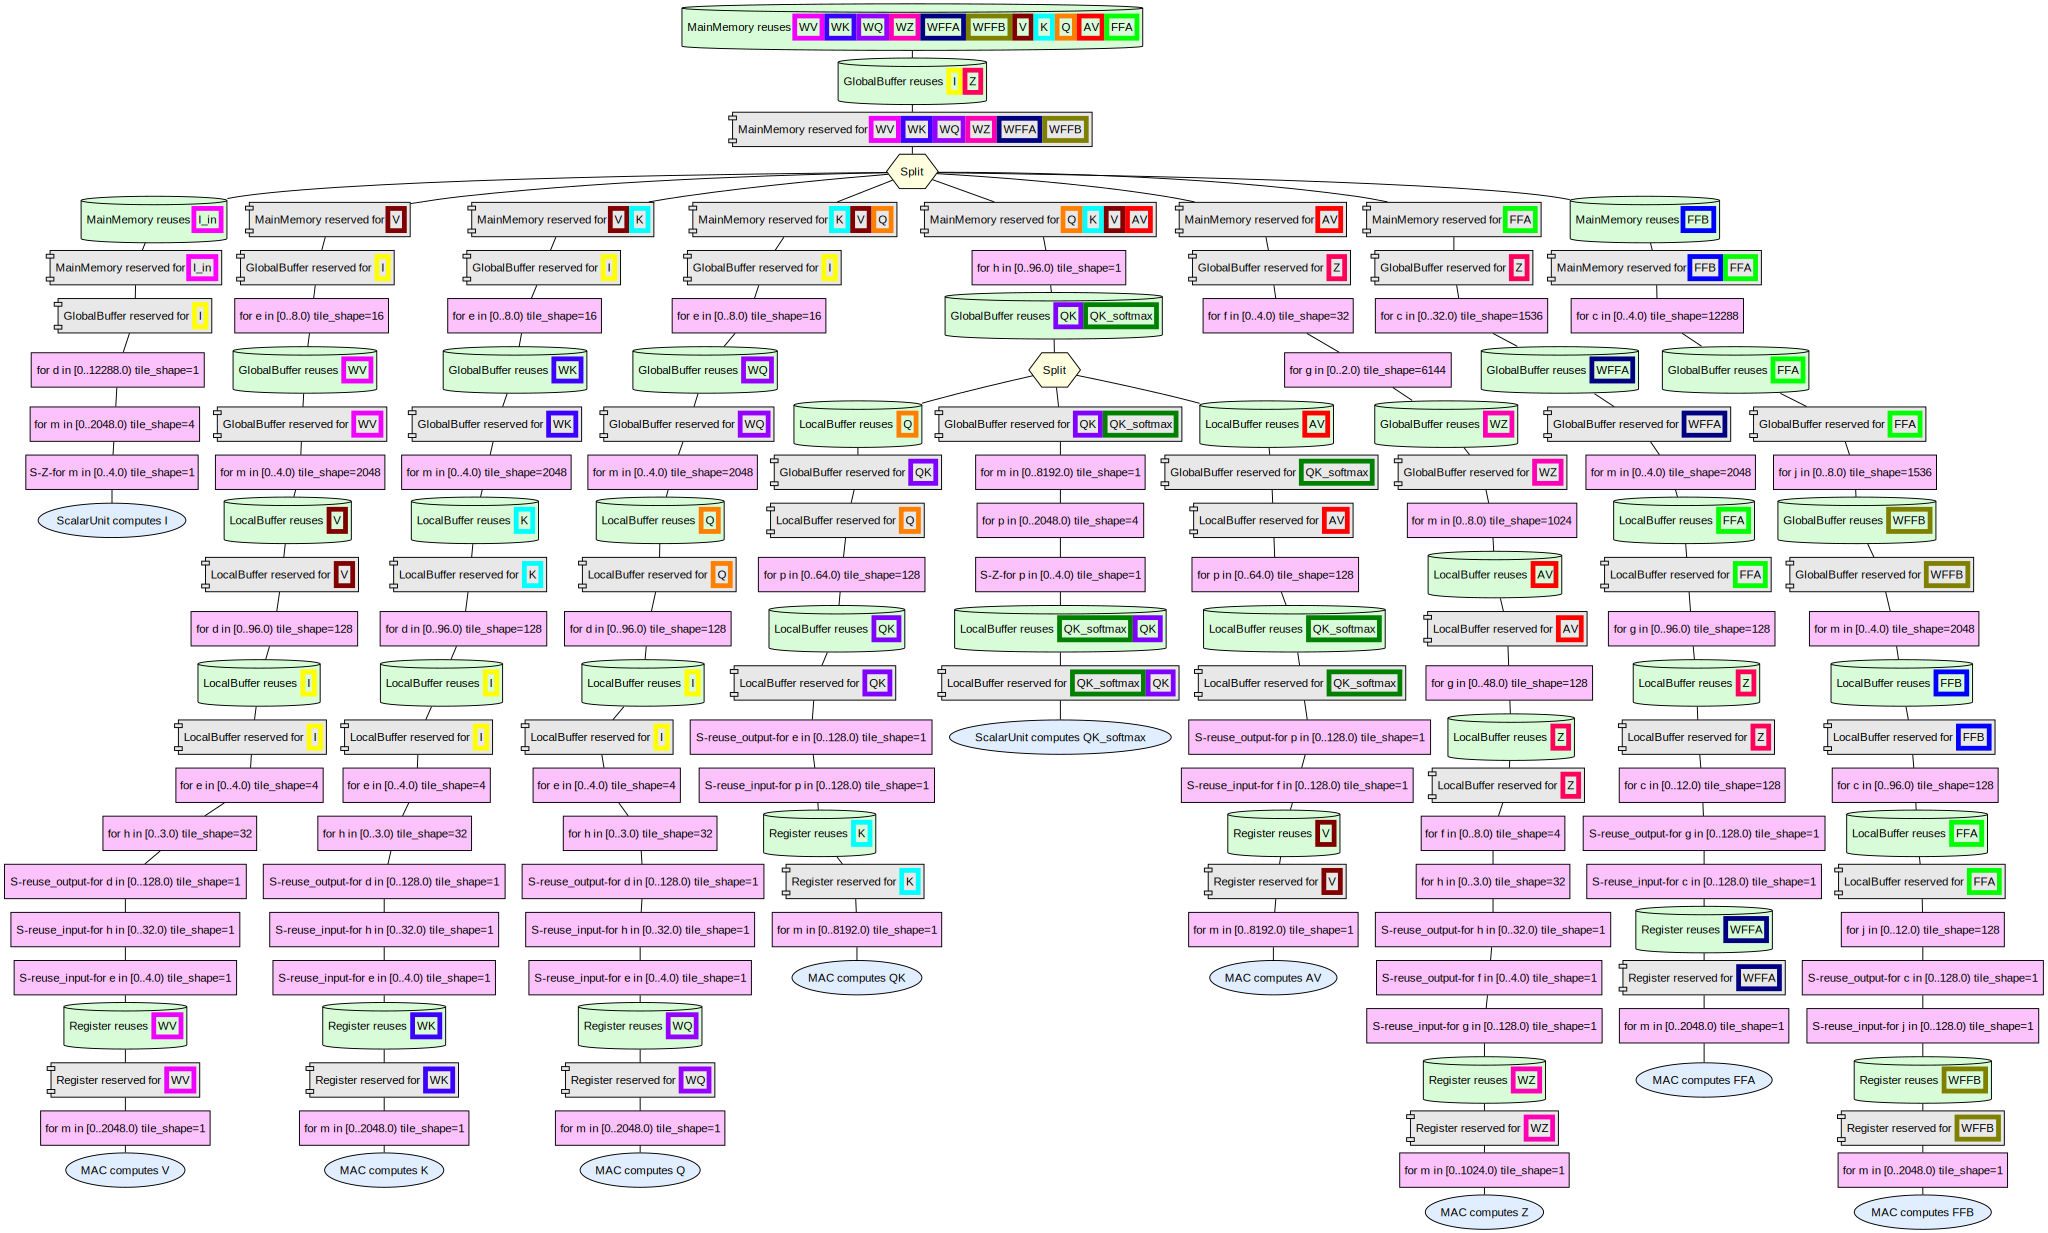

In [9]:
best_mapping = results.mapping(0)

best_mapping

In [8]:
# best_mapping.to_yaml("../mappings/generated_gpt3_tpu.yaml")
# print(best_mapping.model_dump())

'nodes:\n  - tensors:\n      - WV\n      - WK\n      - WQ\n      - WZ\n      - WFFA\n      - WFFB\n      - V\n      - K\n      - Q\n      - AV\n      - FFA\n    component: MainMemory\n    component_object:\n        name: MainMemory\n        spatial: []\n        component_class: null\n        component_model: null\n        component_modeling_log:\n          - Calculating energy for MainMemory action read.\n          - Setting MainMemory energy to action.energy=7.03e-12\n          - Calculating energy for MainMemory action write.\n          - Setting MainMemory energy to action.energy=7.03e-12\n          - Calculating latency for MainMemory action read.\n          - Setting MainMemory latency to action.latency=2.0358306188925081e-13\n          - Calculating latency for MainMemory action write.\n          - Setting MainMemory latency to action.latency=2.0358306188925081e-13\n          - Using predefined leak power value self.leak_power=0\n          - Calculating energy for MainMemory acti

In [13]:
from accelforge.frontend.mapping import (
    Temporal, Spatial, Storage, Compute, Sequential, Nested,
Toll, Split, Pipeline
)

def node_to_yaml_lines(node, indent=0):
    """Convert a mapping node to YAML lines (without
  component_object)."""
    prefix = "  " * indent
    lines = []
    node_type = type(node).__name__

    if isinstance(node, (Storage, Toll)):
        lines.append(f"{prefix}- !{node_type}")
        lines.append(f"{prefix}  component: {node.component}")
        lines.append(f"{prefix}  tensors: {list(node.tensors)}")
        if hasattr(node, 'persistent') and node.persistent:
            lines.append(f"{prefix}  persistent: true")

    elif isinstance(node, Temporal):
        lines.append(f"{prefix}- !Temporal")
        lines.append(f"{prefix}  rank_variable: {node.rank_variable}")
        lines.append(f"{prefix}  tile_shape: {node.tile_shape}")
    elif isinstance(node, Spatial):
          lines.append(f"{prefix}- !Spatial")
          lines.append(f"{prefix}  rank_variable: {node.rank_variable}")
          lines.append(f"{prefix}  component: {node.component}")
          lines.append(f"{prefix}  name: {node.name}")
          lines.append(f"{prefix}  tile_shape: {node.tile_shape}")

    elif isinstance(node, Compute):
        lines.append(f"{prefix}- !Compute")
        lines.append(f"{prefix}  einsum: {node.einsum}")
        lines.append(f"{prefix}  component: {node.component}")

    elif isinstance(node, (Sequential, Nested, Split, Pipeline)):
        lines.append(f"{prefix}- !{node_type}")
        if hasattr(node, 'nodes') and node.nodes:
            lines.append(f"{prefix}  nodes:")
            for child in node.nodes:
                lines.extend(node_to_yaml_lines(child, indent +2))
    return lines
    
yaml_lines = ["mapping:", "  nodes:"]
for node in best_mapping.nodes:
    yaml_lines.extend(node_to_yaml_lines(node, 2))
yaml_content = "\n".join(yaml_lines)

# Save
with open("../mappings/mapper_generated_clean.yaml", 'w') as f:
    f.write(yaml_content)

print("✓ Saved to ../mappings/mapper_generated_clean.yaml")
print("\nFirst 100 lines:")
print("\n".join(yaml_content.split("\n")[:100]))

✓ Saved to ../mappings/mapper_generated_clean.yaml

First 100 lines:
mapping:
  nodes:
    - !Storage
      component: MainMemory
      tensors: ['WV', 'WK', 'WQ', 'WZ', 'WFFA', 'WFFB', 'V', 'K', 'Q', 'AV', 'FFA']
      persistent: true
    - !Storage
      component: GlobalBuffer
      tensors: ['I', 'Z']
    - !Sequential
      nodes:
        - !Nested
          nodes:
            - !Storage
              component: MainMemory
              tensors: ['I_in']
            - !Temporal
              rank_variable: d
              tile_shape: 1
            - !Temporal
              rank_variable: m
              tile_shape: 4
            - !Spatial
              rank_variable: m
              component: LocalBuffer
              name: Z
              tile_shape: 1
            - !Compute
              einsum: I
              component: ScalarUnit
        - !Nested
          nodes:
            - !Temporal
              rank_variable: e
              tile_shape: 16
            - !Storage
   

In [8]:
# Analyze the results for data dependent
print(get_energy(results))

print(get_cycles(results))

print("MainMemory: ", get_component_energy(results, 'MainMemory'))
print("GlobalBuffer: ", get_component_energy(results, 'GlobalBuffer'))
print("LocalBuffer: ", get_component_energy(results, 'LocalBuffer'))
print("ProcessingElement: ", get_component_energy(results, 'ProcessingElement'))
print("Register: ", get_component_energy(results, 'Register'))
print("ScalarUnit: ", get_component_energy(results, 'ScalarUnit'))
print("MAC: ", get_component_energy(results, 'MAC'))

3.2830834839383325
0.9708690657862462
MainMemory:  0.24343605991452932
GlobalBuffer:  0.743845404474996
LocalBuffer:  0.910417368434632
ProcessingElement:  0.0
Register:  0.0
ScalarUnit:  0.0
MAC:  1.3853846509977599


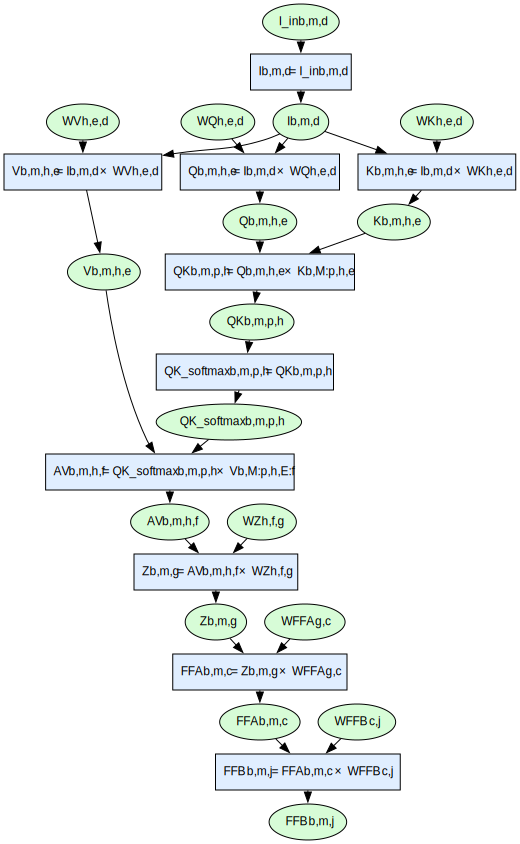

In [9]:
spec.workload

In [13]:
best_mapping = results.data.iloc[0]

print(best_mapping)

tensor<SEP>I                                                                     0.75
Total<SEP>latency                                                            0.970869
Total<SEP>energy                                                             3.283083
Total<SEP>leak_energy                                                               0
Total<SEP>dynamic_energy                                                     3.283083
                                                          ...                        
FFB<SEP>latency<SEP>GlobalBuffer                                             0.002753
FFB<SEP>latency<SEP>MainMemory                                               0.002787
FFB<SEP>latency<SEP>Register                                                        0
FFB<SEP>mapping                     {'nodes': [{'component': 'MainMemory', 'compon...
Total<SEP>mapping                   <accelforge.mapper.FFM._join_pmappings.join_pm...
Name: 0, Length: 464, dtype: object


# Parallel Workload (All I_in)

In [10]:
# Load architecture and workload specifications
spec_all_i_in = Spec.from_yaml(
    examples.arches.tpu_v4i,
    "../workloads/gpt3_175B_all_I_in.yaml"
)


# Map the workload to the architecture
results_all_i_in = spec_all_i_in.map_workload_to_arch()

Getting energy, latency, and leak power for components running FFB: 100
Generating pmapping templates for compute ScalarUnit Einsum K: 0it [00:00, ?it/s]], ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum AV: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum Z: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum V: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum QK: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum I: 1it [00:00, 17.56it/s]
Generating pmapping templates for compute ScalarUnit Einsum Q: 0it [00:00, ?it/s]0, 43.46it/s]
Generating pmapping templates for compute MAC Einsum I: 0it [00:00, ?it/s]]
Generating pmapping templates for compute MAC Einsum AV: 6it [00:00, 21.23it/s]t/s], 44.13it/s]
Generating pmapping templates for compute ScalarUnit Einsum QK_softmax: 16it [00:00, 37.93it/s]
Generating pmapping templates for compute MAC Einsum QK_so

Einsum I has 1 pmapping job:
	0	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  ScalarUnit computes I
Einsum V has 32 pmapping jobs:
	0	[WV in MainMemory] [V in MainMemory] [I_in in MainMemory] T-b  T-d  T-m  S-Z-m  S-Z-h  S-Z-e  S-Z-d  S-Z-b  [I_in in LocalBuffer] T-e  T-h  [V in LocalBuffer] T-d  S-reuse_output-d  S-reuse_input-h  S-reuse_input-e  [WV in Register] T-b  T-m  MAC computes V
	1	[WV in MainMemory] [V in MainMemory] [I_in in MainMemory] T-b  T-e  T-h  T-m  S-Z-m  S-Z-h  S-Z-e  S-Z-d  S-Z-b  [V in LocalBuffer] T-d  [I_in in LocalBuffer] T-e  T-h  S-reuse_output-d  S-reuse_input-h  S-reuse_input-e  [WV in Register] T-b  T-m  MAC computes V
	2	[WV in MainMemory] [V in MainMemory] [I_in in MainMemory] T-b  T-d  T-m  [I_in in GlobalBuffer] S-Z-m  S-Z-h  S-Z-e  S-Z-d  S-Z-b  [I_in in LocalBuffer] T-e  T-h  [V in LocalBuffer] T-d  S-reuse_output-d  S-reuse_input-h  S-reuse_input-e  [WV in Register] T-b  T-m  MAC computes V
	3	[WV in MainMemory] [V in M

Generating pmappings:  20%|██▏        | 58/295 [03:35<10:39,  2.70s/it]

KeyboardInterrupt: 

In [ ]:
spec_all_i_in.workload

In [ ]:
# Analyze the results for parallel
print(get_energy(results_all_i_in))

print(get_cycles(results_all_i_in))

print("MainMemory: ", get_component_energy(results_all_i_in, 'MainMemory'))
print("GlobalBuffer: ", get_component_energy(results_all_i_in, 'GlobalBuffer'))
print("LocalBuffer: ", get_component_energy(results_all_i_in, 'LocalBuffer'))
print("ProcessingElement: ", get_component_energy(results_all_i_in, 'ProcessingElement'))
print("Register: ", get_component_energy(results_all_i_in, 'Register'))
print("ScalarUnit: ", get_component_energy(results_all_i_in, 'ScalarUnit'))
print("MAC: ", get_component_energy(results_all_i_in, 'MAC'))

In [ ]:
results

# Parallel Workload (All renamed)

In [ ]:
# Load architecture and workload specifications
spec_all_renamed = Spec.from_yaml(
    examples.arches.tpu_v4i,
    "../workloads/gpt3_175B_all_renamed.yaml"
)


# Map the workload to the architecture
results_all_renamed = spec_all_renamed.map_workload_to_arch()

In [ ]:
spec_all_renamed.workload

In [ ]:
# Analyze the results for all renamed
print(get_energy(results_all_renamed))

print(get_cycles(results_all_renamed))

print("MainMemory: ", get_component_energy(results_all_renamed, 'MainMemory'))
print("GlobalBuffer: ", get_component_energy(results_all_renamed, 'GlobalBuffer'))
print("LocalBuffer: ", get_component_energy(results_all_renamed, 'LocalBuffer'))
print("ProcessingElement: ", get_component_energy(results_all_renamed, 'ProcessingElement'))
print("Register: ", get_component_energy(results_all_renamed, 'Register'))
print("ScalarUnit: ", get_component_energy(results_all_renamed, 'ScalarUnit'))
print("MAC: ", get_component_energy(results_all_renamed, 'MAC'))

In [ ]:
results_all_renamed